In [ ]:
# | echo: false
from IPython.display import HTML, display, Math, Latex
from sympy import latex, init_printing
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import mechanicskit as mk
from mechanicskit import display_labeled_latex

# Systematic Truss Analysis

This chapter introduces a systematic approach to analyzing truss structures using the [direct stiffness method](https://en.wikipedia.org/wiki/Direct_stiffness_method), see e.g., @Ottosen1992, @Przemieneicki1968, and @McGuire2000. The objective is to express equilibrium and compatibility in linear algebra form ($\mathbf{K u = f}$), assemble element contributions into a global system, and implement the entire pipeline in python code.

This skill is foundational for upcoming courses where we implement our own Finite Element Methods and is essential for understanding the numerics behind the FEA software we use. The emphasis is on numerical formulation—rather than doing structural analysis by hand—using clear data structures, robust assembly, reproducible solvers, and automated post-processing.

## Introduction to Truss Analysis



A truss is a structural assembly composed of slender members connected at joints, where each member is assumed to carry only axial forces (tension or compression). The approach we develop here is known as the **direct stiffness method** [@Przemieneicki1968; @McGuire2000], which forms the basis of modern matrix structural analysis.

The essence of our approach lies in recognizing that any truss element, regardless of its orientation in space, behaves locally as a simple one-dimensional rod. By establishing a transformation between local element coordinates and global structural coordinates, we can systematically assemble the global stiffness matrix and solve for nodal displacements. From these displacements, we recover member forces, stresses, and strains—the quantities that mechanical engineers need for design and analysis.


![1D rod element](graphics/SystematicTrussAnalysis_1D_rod.png){fig-align="center" width=300}

## The One-Dimensional Rod Element

We begin with the simplest structural element: a one-dimensional rod of length $L$, cross-sectional area $A$, and Young's modulus $E$. When the rod is aligned with its axis (the local $x'$-direction), the relationship between the axial force $N$ and the displacement difference between its two ends follows directly from Hooke's law:

$$
N=k \underbrace{\left(u_2-u_1\right)}_\delta
$$

here, we recognize the difference in displacement at the deformation of the rod, i.e.,
$$
\delta = u_2 - u_1
$$

furthermore, the element stiffness is given by $k=\frac{EA}{L}$. 

With $N=f_2$ and $f_1=-N$, we can write

$$
\left\{\begin{array}{l}
f_2=k\left(u_2-u_1\right) \\
f_1=k\left(u_1-u_2\right)
\end{array}\right.
$$

or on matrix form

$$
k\left[\begin{array}{cc}
1 & -1 \\
-1 & 1
\end{array}\right]\left[\begin{array}{l}
u_1 \\
u_2
\end{array}\right]=\left[\begin{array}{l}
f_1 \\
f_2
\end{array}\right]
$$

or 

$$
\mathbf{K}_e \mathbf{u}=\mathbf{f}
$$



### Element Stiffness Matrix in Local Coordinates


Now, consider some arbitrary rod in a two dimensional setting.

![Truss structure](graphics/SystematicTrussAnalysis_2D_truss.png){fig-align="center" width=300}

Each node can be translated in the x- and y-direction and each node can carry loads in x- and y-directions.


To formulate the element equations systematically, we introduce the concept of the element stiffness matrix. In local coordinates, each element has four degrees of freedom: two displacement components at each end node. However, for a rod that carries only axial loads, the transverse components (perpendicular to the rod axis) do not participate in the force-displacement relationship.

![Local and global coordinates](graphics/SystematicTrussAnalysis_LocalCoordinates.svg){fig-align="center" width=400}

Each rod has a local coordinate system $x'$ and $y'$ and local node numbers 1 and 2 . The local coordinate system is rotated compared to the global coordinate system, and the angle is denoted by $\theta$. In the local coordinates we have

$$
\begin{cases}k\left(u_1'-u_3'\right) & =f_1' \\ 0 & =f_2^{\prime} \\ k\left(u_3^{\prime}-u_1^{\prime}\right) & =f_3^{\prime} \\ 0 & =f_4^{\prime}\end{cases}
$$



where indices  [1]{color="mblue"} and [2]{color="mblue"} refer to the first node (axial and transverse directions), and indices [3]{color="mblue"} and [4]{color="mblue"} refer to the second node. The above relation can be written on matrix form:

$$
k\left[\begin{array}{cccc}
1 & 0 & -1 & 0 \\
0 & 0 & 0 & 0 \\
-1 & 0 & 1 & 0 \\
0 & 0 & 0 & 0
\end{array}\right]\left[\begin{array}{c}
u_1^{\prime} \\
u_2^{\prime} \\
u_3^{\prime} \\
u_4^{\prime}
\end{array}\right]=\left[\begin{array}{c}
f_1^{\prime} \\
f_2^{\prime} \\
f_3^{\prime} \\
f_4^{\prime}
\end{array}\right]
$$


or

$$
\boxed{\mathbf{K}'_e \mathbf{u}' = \mathbf{f}'}
$$ {#eq-local-equilibrium} 




where the **local element stiffness** matrix is:

$$
\mathbf{K}'_e = k \begin{bmatrix}
1 & 0 & -1 & 0 \\
0 & 0 & 0 & 0 \\
-1 & 0 & 1 & 0 \\
0 & 0 & 0 & 0
\end{bmatrix}
$$

Note that this matrix is singular (has zero determinant) because two degrees of freedom are unconstrained. This is expected for a rod element that has no stiffness in the transverse direction.

## Coordinate Transformation


In a 2D truss, individual rod elements can be oriented at any angle, meaning their natural axial direction will likely not align with the global X and Y axes used for the overall structure. This misalignment requires us to express the stiffness of each element in the global frame before they can be combined into a global stiffness. We achieve this by applying a coordinate transformation to each element’s local stiffness matrix. By rotating the local stiffness properties into the global system, we can systematically assemble the contributions from all elements to form the stiffness matrix for the entire truss.

![Transformation geometry](graphics/SystematicTrussAnalysis_Transformation.svg){fig-align="center" width=300}

Consider a truss element oriented at an arbitrary angle $\theta$ with respect to the global $x$-axis. The local coordinate system $(x', y')$ is aligned with the rod axis, while the global system $(x, y)$ is fixed in space. We need a relation between $\mathbf{u}_e^{\prime}$ and $u_i$ and $u_j$. The local entities of each rod need to be expressed in terms of global coordinates for unification, i.e., such that we can combine them into a structure. Let's express the local displacements in terms of global displacements using the angle $\theta$:

$$
\left\{\begin{array}{l}
u_i^x=u_1^{\prime} \cos \theta-u_2^{\prime} \sin \theta \\
u_i^y=u_1^{\prime} \sin \theta+u_2^{\prime} \cos \theta \\
u_j^x=u_3^{\prime} \cos \theta-u_4^{\prime} \sin \theta \\
u_j^y=u_3^{\prime} \sin \theta+u_4^{\prime} \cos \theta
\end{array}\right.
$$

writing things in matrix form allows us to uncover matrices with interesting properties, we rewrite the equations above on matrix form:

$$
\left[\begin{array}{c}
u_i^x \\
u_i^y \\
u_j^x \\
u_j^y
\end{array}\right]=\left[\begin{array}{cccc}
\cos \theta & -\sin \theta & 0 & 0 \\
\sin \theta & \cos \theta & 0 & 0 \\
0 & 0 & \cos \theta & -\sin \theta \\
0 & 0 & \sin \theta & \cos \theta
\end{array}\right]\left[\begin{array}{c}
u_1^{\prime} \\
u_2^{\prime} \\
u_3^{\prime} \\
u_4^{\prime}
\end{array}\right]
$$

here that matrix is known as the transformation matrix $\mathbf L^\mathsf T$, we can write the expression more compactly as

$$
\mathbf{u}_e=\mathbf{L}^T \mathbf{u}_e^{\prime}
$$

### The Transformation Matrix



The displacement components in global coordinates $(u, v)$ relate to local coordinates $(u', v')$ through the rotation transformation:

$$
\begin{bmatrix}
u' \\
v'
\end{bmatrix} = 
\begin{bmatrix}
\cos\theta & \sin\theta \\
-\sin\theta & \cos\theta
\end{bmatrix}
\begin{bmatrix}
u \\
v
\end{bmatrix}
$$



This rotation matrix transforms displacement vectors from global to local coordinates. For the complete element with two nodes (four degrees of freedom), we construct the transformation matrix $\mathbf{L}$ by applying the rotation to each node:

$$
\boxed{\mathbf{L} = \begin{bmatrix}
\cos\theta & \sin\theta & 0 & 0 \\
-\sin\theta & \cos\theta & 0 & 0 \\
0 & 0 & \cos\theta & \sin\theta \\
0 & 0 & -\sin\theta & \cos\theta
\end{bmatrix}}
$$



An important property of this matrix is that it is orthogonal, meaning:

$$
\mathbf{L}^\mathsf{T} \mathbf{L} = \mathbf{L} \mathbf{L}^\mathsf{T} = \mathbf{I} \quad \text{and} \quad \mathbf{L}^{-1} = \mathbf{L}^\mathsf{T}
$$


This orthogonality has profound physical significance. The strain energy stored in a deformed element is given by $U = \frac{1}{2}\mathbf{u}^\mathsf{T}\mathbf{K}\mathbf{u}$. Since a rotation is merely a change in perspective (how we describe the same physical configuration), the energy must remain unchanged regardless of which coordinate system we use. Mathematically, the orthogonality of $\mathbf{L}$ ensures that the quadratic form $\mathbf{u}^\mathsf{T}\mathbf{K}\mathbf{u}$ is preserved under the transformation, meaning the calculated strain energy is identical whether computed in local or global coordinates. This consistency is essential: if the energy changed with coordinate system choice, our analysis would yield different results depending on an arbitrary modeling decision rather than the underlying physics.


Using the transformation matrix we can transform local quantities to global

$$
\mathbf{u}_e^{\prime}=\mathbf{L}^T \mathbf{u}_e^{\prime} \Leftrightarrow \mathbf{u}_e^{\prime}=\mathbf{L} \mathbf{u}_e
$$ {#eq-transformation-displacements}

and

$$
\mathbf{f}_e=\mathbf{L}^T \mathbf{f}_e^{\prime} \Leftrightarrow \mathbf{f}_e^{\prime}=\mathbf{L} \mathbf{f}_e
$$ {#eq-transformation-forces}

Inserting (@eq-transformation-displacements) and (@eq-transformation-forces) into the global equilibrium equation (@eq-local-equilibrium) gives

$$
\mathbf{L}^T \mathbf{K}_e^{\prime} \mathbf{L} \mathbf{u}_e=\mathbf{f}_e
$$

or

$$
\mathbf{S}_e \mathbf{u}_e=\mathbf{f}_e
$$

where $\mathbf{S}_e$ is known as the **element stiffness matrix in global coordinates**.


$$
\boxed{\mathbf{S}_e = \mathbf{L}^\mathsf{T} \mathbf{K}'_e \mathbf{L}}
$$


## How to compute the transformatin matrix $\mathbf L^\mathsf T$

![Rod vector computation](graphics/SystematicTrussAnalysis_RodVector.png){fig-align="center" width=200}

A clever computational trick avoids the need to explicitly compute angles. Given the coordinates of the two nodes defining an element, we can compute the rod vector $\mathbf{r} = \mathbf{p}_2 - \mathbf{p}_1$ and normalize it:

$$
\hat{\mathbf{r}}=\frac{\mathbf{r}}{|\mathbf{r}|}=\left[\begin{array}{c}
\cos \theta \\
\sin \theta
\end{array}\right]=:\left[\begin{array}{c}
c \\
s
\end{array}\right]
$$

such that we get

$$
\mathbf{L}^T=\left[\begin{array}{cccc}
c & -s & 0 & 0 \\
s & c & 0 & 0 \\
0 & 0 & c & -s \\
0 & 0 & s & c
\end{array}\right]
$$


Carrying out this matrix multiplication with $c = \cos\theta$ and $s = \sin\theta$, we obtain the explicit form of the global element stiffness matrix:

$$
\mathbf{S}_e = k \begin{bmatrix}
c^2 & cs & -c^2 & -cs \\
cs & s^2 & -cs & -s^2 \\
-c^2 & -cs & c^2 & cs \\
-cs & -s^2 & cs & s^2
\end{bmatrix}
$$



This matrix is symmetric, as required for a conservative mechanical system. It also has a beautiful structure: the diagonal $2 \times 2$ blocks are identical, and the off-diagonal blocks are their negatives, reflecting the action-reaction principle.

## Post-Processing: Member Quantities

![](graphics/SystematicTrussAnalysis.png){fig-align="center" width=400}


After solving for nodal displacements, we need to recover the member forces and stresses. These quantities are essential for structural design. The key insight is that the member deformation (elongation) can be extracted directly from the global displacement vector.


### Element Deformation


![](graphics/SystematicTrussAnalysis-1.png){fig-align="center" width=300}


The deformation of an element is the change in its length, which corresponds to the relative displacement of its end nodes in the axial direction. From the figure we can see that the deformation of the rod is

$$
\delta=\Delta u=\left(u_j^x \cos \theta+u_j^y \sin \theta\right)-\left(u_i^x \cos \theta+u_i^y \sin \theta\right)
$$

This can be written om matrix form as

$$
\delta=\underbrace{\left[\begin{array}{llll}
-c & -s & c & s
\end{array}\right]}_{\mathbf{T}}\left[\begin{array}{c}
u_i^x \\
u_i^y \\
u_j^x \\
u_j^y
\end{array}\right]=\mathbf{T} \cdot \mathbf{u}_e
$$

where $\mathbf T$ is known as the **transformation vector** that projects the nodal displacements onto the rod axis direction. We thus have



$$
\boxed{\delta = \mathbf{T} \cdot \mathbf{u}_e}
$$




### Member Force

The axial force in the member follows directly from the deformation:

$$
\boxed{N = k \delta = \frac{EA}{L} \mathbf{T} \cdot \mathbf{u}_e}
$$

A positive value indicates tension, while a negative value indicates compression.



### Strain and Stress

The engineering strain is the deformation divided by the original length:

$$
\boxed{\varepsilon = \frac{\delta}{L}}
$$

Note that the length of the element $L$ can be computed from the nodal coordinates as

$$
L = |\mathbf r| = | \mathbf p_j - \mathbf p_i |
$$

The axial stress follows from Hooke's law or directly from the force:

$$
\boxed{\sigma = \frac{N}{A} = E\varepsilon}
$$

These relationships allow us to assess whether the structure remains within acceptable stress limits and to understand the load paths through the truss.

### Element load vector (or reaction force vector)

$$
\mathbf{f}^e=\mathbf{T}^T N=k \mathbf{T}_{4 \times 1}^T \mathbf{T}_{1 \times 4} \mathbf{u}_{4 \times 1}^e=k\left[\begin{array}{c}
-c \\
-s \\
c \\
s
\end{array}\right]\left[\begin{array}{llll}
-c & -s & c & s
\end{array}\right]\left[\begin{array}{c}
u_i^x \\
u_i^y \\
u_j^x \\
u_j^y
\end{array}\right]
$$

or

$$
\left[\begin{array}{l}
f_i^x \\
f_i^y \\
f_j^x \\
f_j^y
\end{array}\right]=\underbrace{\frac{E A}{L}\left[\begin{array}{cccc}
c^2 & c s & -c^2 & -c s \\
c s & s^2 & -c s & -s^2 \\
-c^2 & -c s & c^2 & c s \\
c s & -s^2 & c s & s^2
\end{array}\right]}_{\mathbf{S}_e}\left[\begin{array}{c}
u_i^x \\
u_i^y \\
u_j^x \\
u_j^y
\end{array}\right]
$$

## Implementation in Python

Now we translate this theoretical framework into a computational workflow. The implementation follows the conceptualize-formulate-compute-analyze pattern that characterizes modern computational mechanics. We shall use SymPy for symbolic manipulation and NumPy for numerical computation, allowing us to see both the mathematical structure and the numerical results.

### Symbolic Derivation of Element Stiffness

Let us first verify the element stiffness matrix transformation symbolically. This provides confidence in our implementation and reveals the mathematical structure.

In [2]:
# | code-fold: false
import sympy as sp

# Define symbolic variables
theta, k = sp.symbols("theta k", real=True, positive=True)
c, s = sp.cos(theta), sp.sin(theta)

# Local element stiffness matrix (template)
K_prime = k * sp.Matrix([[1, 0, -1, 0], [0, 0, 0, 0], [-1, 0, 1, 0], [0, 0, 0, 0]])


In [3]:
# | echo: false
display_labeled_latex("\\mathbf k' = ", K_prime)

<IPython.core.display.Latex object>

In [4]:
# | code-fold: false
# Transformation matrix (L^T maps global to local)
L_T = sp.Matrix([[c, -s, 0, 0], [s, c, 0, 0], [0, 0, c, -s], [0, 0, s, c]])

In [5]:
# | echo: false
display_labeled_latex("\\mathbf L^\\mathsf T = ", L_T)


<IPython.core.display.Latex object>

Let's verify the orthogonality property of the transformation matrix:

In [6]:
# | code-fold: false
# Verify L^T * L = I
identity_check = sp.trigsimp(L_T * L_T.T)
identity_check

Matrix([
[1, 0, 0, 0],
[0, 1, 0, 0],
[0, 0, 1, 0],
[0, 0, 0, 1]])

As expected, we obtain the identity matrix, confirming orthogonality. Now we compute the global element stiffness:

In [7]:
# | code-fold: false
# Global element stiffness: S_e = L^T * K'_e * L
S_e = sp.trigsimp(L_T.T * K_prime * L_T)

In [8]:
# | echo: false
display_labeled_latex("\\mathbf S_e = ", S_e, arrayStretch=2.0)

<IPython.core.display.Latex object>

### Verification at Special Angles

To build confidence in our derivation, let's evaluate the global stiffness matrix at specific angles where we can verify the result by inspection.

In [9]:
# | code-fold: false
# At theta = 0 (horizontal rod)
S_e_0 = S_e.subs(theta, 0)
S_e_0

Matrix([
[ k, 0, -k, 0],
[ 0, 0,  0, 0],
[-k, 0,  k, 0],
[ 0, 0,  0, 0]])

For $\theta = 0$, the rod is horizontal, so the axial direction aligns with the global $x$-axis. The stiffness matrix shows coupling only in the $x$-direction (indices 0 and 2), which is exactly what we expect.

In [10]:
# | code-fold: false
# At theta = 90 degrees (vertical rod)
S_e_90 = S_e.subs(theta, sp.pi / 2)
S_e_90

Matrix([
[0,  0, 0,  0],
[0,  k, 0, -k],
[0,  0, 0,  0],
[0, -k, 0,  k]])

For $\theta = 90°$, the rod is vertical, and the stiffness couples only the $y$-direction displacements (indices 1 and 3). This confirms our transformation is working correctly.

## Complete Truss Solver in 2D - Python implementation

We implement the complete truss analysis following a systematic workflow: define geometry, assemble global stiffness, apply boundary conditions, solve for displacements, and compute member quantities.

Let us analyze a structure as an example and look at the implementation details in python.

![Example truss](graphics/SystematicTrussAnalysis-2.png){fig-align="center" width=400}

In [11]:
# | code-fold: false
import numpy as np
import matplotlib.pyplot as plt

# Node coordinates [x, y] in mm
nodes = np.array(
    [
        [0, 0],  # Node 1
        [500, 0],  # Node 2
        [300, 300],  # Node 3
        [600, 300],  # Node 4
    ]
)

# Element connectivity (0-indexed)
elements = np.array(
    [
        [0, 1],  # Element 1: Node 1 to Node 2
        [0, 2],  # Element 2: Node 1 to Node 3
        [1, 2],  # Element 3: Node 2 to Node 3
        [1, 3],  # Element 4: Node 2 to Node 4
        [2, 3],  # Element 5: Node 3 to Node 4
    ]
)


**Problem statement:**

Given the structure above, determine all displacements, member forces, deformations, strains and stresses as well as reaction forces in the supports.

**Solution**

The coordinates are given by the variables `nodes` and the `elements` define the node connectivity. The order of the columns in `elements` is not important.

Using the topological data from above, we can visualize the truss structure in Python as follows:

In [ ]:
# | code-fold: true
# | fig-cap: "The truss structure with node and element numbering."
import matplotlib.patches as patches
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.set_aspect("equal")
ax.axis("off")

# Draw elements using mk.patch()
mk.patch('Faces', elements, 'Vertices', nodes,
         'EdgeColor', 'black', 'LineWidth', 2)

# Node dots
ax.plot(
    nodes[:, 0],
    nodes[:, 1],
    marker="o",
    markeredgecolor="k",
    markerfacecolor="c",
    markersize=14,
    linestyle="None",
)

nnod = nodes.shape[0]

# Node numbering
for i in range(nnod):
    # Use str(i + 1) to get 1-based node numbers
    ax.text(
        nodes[i, 0] + 3,
        nodes[i, 1],
        str(i + 1),
        horizontalalignment="right",  # 'right' aligns text left of point
        verticalalignment="center",
        fontsize=8,
    )

# Element numbering
# We use enumerate to get a 0-based index 'i'
for i, element_nodes in enumerate(elements):
    # Find the midpoint of the element
    mid_point = np.mean(nodes[element_nodes], axis=0)
    xm = mid_point[0]
    ym = mid_point[1]

    # We use str(i + 1) to get 1-based element numbers
    label = str(i + 1)
    ax.text(
        xm,
        ym,
        label,
        backgroundcolor="y",
        horizontalalignment="center",
        verticalalignment="center",
        fontsize=8,
        fontweight="normal",
    )

The total number of degrees of freedom (or equations), $n_{\text {dof }}$ is given by

$$
n_{\mathrm{dof}}=n_{\mathrm{nod}} \cdot n_{\mathrm{loc}}=4 \cdot 2=8
$$

where $n_{\text {nod }}$ is the number of nodes and $n_{\text {loc }}$ is the number of local degrees of freedom per node.



The global displacement field and load field are given by

$$
\mathbf{u}=\left[\begin{array}{c}
u_1^x=0 \\
u_1^y=0 \\
u_2^x \\
u_2^y=0 \\
u_3^x \\
u_3^y \\
u_4^x \\
u_4^y
\end{array}\right], \mathbf{f}=\left[\begin{array}{c}
f_1^x=0 \\
f_1^y=0 \\
f_2^x=0 \\
f_2^y=0 \\
f_3^x=0 \\
f_3^y=0 \\
f_4^x=0 \\
f_4^y=-P
\end{array}\right]
$$


With the resulting linear system taking the form of

$$
\mathbf{S}_{8 \times 8} \mathbf{u}_{8 \times 1}=\mathbf{f}_{8 \times 1} 
$${#eq-global-equilibrium}

The unknown displacements are computed by establishing the global stiffness matrix (system matrix) $\mathbf S$. Creating the linear system (@eq-global-equilibrium), applying boundary conditions, and solving for $\mathbf u$. This is done by the following steps:

1. Initialize the global stiffness matrix $\mathbf{S}$ as an $n_{\text {dof }} \times n_{\text {dof }}$ zero matrix.
2. Loop over each element to compute its contribution to the global stiffness matrix:
3. Extract the node indices and coordinates for the current element.
4. Compute the length and orientation of the element.
5.  Construct the transformation matrix $\mathbf{L}$.
6. Compute the local stiffness matrix $\mathbf{K}'_e$.
7. Transform to global coordinates to obtain $\mathbf{S}_e$.
8. Assemble $\mathbf{S}_e$ into the global stiffness matrix $\mathbf{S}$ at the appropriate indices.
9. Add the element load vector to the global load vector.
10. Apply boundary conditions by modifying $\mathbf{S}$ and $\mathbf{f}$ to account for fixed supports.
11. Solve the modified linear system for the unknown displacements $\mathbf{u}$.

### Step by step implementation

We begin with some preliminaries and initialize the global system matrix and vectors using the number of degrees of freedom.

In [13]:
# | code-fold: false
nele = elements.shape[0]  # number of elements
nnod = nodes.shape[0]  # number of nodes
ndofs = nnod * 2  # 2 DOF per node (u_x, u_y)

S = np.zeros((ndofs, ndofs))  # Global stiffness matrix
f = np.zeros(ndofs)  # Global force vector
u = np.zeros(ndofs)  # Global displacement vector
Sprime = np.array([[1, 0, -1, 0], [0, 0, 0, 0], [-1, 0, 1, 0], [0, 0, 0, 0]])
Ltot = 0  # Total length of truss
E = 210000 * np.ones(nele)  # Young's modulus in MPa
A = 4 * 6 * np.ones(nele)  # Cross-sectional area in mm^2

print(f"Number of elements: {nele}")
print(f"Number of nodes: {nnod}")

Number of elements: 5
Number of nodes: 4


**Element1**

We begin by computing which global degrees of freedom correspond to our first element.


In [14]:
# | code-fold: false
iel = 0  # Element index (0-based)
n1, n2 = elements[iel]  # Nodes for this element


In [15]:
# | echo: false
latex_str = f"Node number for element 0 are: n1={n1} and n2={n2}."
display(HTML(latex_str))

The node numbers correspond to degrees of freedom, for our problem we have two, i.e., $x-$ and $y-$ translation. The data structure of `dofs` is the same as for the displacements and loads above.

In [16]:
# | code-fold: false
# DOF indices for the first element
dofs = np.array([2 * n1, 2 * n1 + 1, 2 * n2, 2 * n2 + 1])

In [17]:
# | echo: false
latex_str = f"Degree of freedom indices for element 0 are: {dofs}."
display(HTML(latex_str))

Computing the element stiffness matrix

In [18]:
# | code-fold: false
p1 = nodes[n1]  # node coordinates
p2 = nodes[n2]  # node coordinates

In [19]:
# | echo: false
latex_str = f"Coordinates of nodes for element 0 are: p1={p1} and p2={p2}."
display(HTML(latex_str))

In [20]:
# | code-fold: false
r = p2 - p1  # element vector

In [21]:
# | echo: false
latex_str = f"Element vector for element 0 is: r={r}."
display(HTML(latex_str))

In [22]:
# | code-fold: false
L = np.linalg.norm(r)  # element length

In [23]:
# | echo: false
latex_str = f"The length of element {iel} is: L={L}."
display(HTML(latex_str))

In [24]:
# | code-fold: false
er = r / L  # unit vector along element

In [25]:
# | echo: false
latex_str = f"The unit vector along element {iel} is: er={er}."
display(HTML(latex_str))

In [26]:
# | code-fold: false
c, s = er[0], er[1]  # direction cosines

In [27]:
# | echo: false
latex_str = f"The cosine and sine of element {iel} are: c={c}, s={s}."
display(HTML(latex_str))

In [28]:
# | code-fold: false
R = np.array([[c, -s], [s, c]])

In [29]:
# | echo: false
latex_str = f"The rotation matrix for element {iel} is:"
display(HTML(latex_str))

display_labeled_latex("\\mathbf R = ", R, 0)

<IPython.core.display.Latex object>

In [30]:
# | code-fold: false
LT = np.block([[R, np.zeros((2, 2))], [np.zeros((2, 2)), R]])

In [31]:
# | echo: false
display_labeled_latex("\\mathbf L^\\mathsf T = ", LT, 0)

<IPython.core.display.Latex object>

In [32]:
# | code-fold: false
Ai = A[iel]
Ei = E[iel]
Ki = Ei * Ai / L
print(f"Element {iel} stiffness: Ki = {Ki} MPa")
print(f"Element {iel} area: Ai = {Ai} mm^2")
print(f"Element {iel} Young's modulus: Ei = {Ei} MPa")
print(f"Element {iel} length: L = {L} mm")

Element 0 stiffness: Ki = 10080.0 MPa
Element 0 area: Ai = 24.0 mm^2
Element 0 Young's modulus: Ei = 210000.0 MPa
Element 0 length: L = 500.0 mm


In [33]:
# | code-fold: false
Se = Ki * LT * Sprime * LT.T

In [34]:
# | echo: false
display_labeled_latex("\\mathbf S_e = ", Se, 0)

<IPython.core.display.Latex object>

### Assembly process

The element stiffness matrix $\mathbf S_e$ needs to be added to the global stiffness matrix $\mathbf S$ at the correct locations corresponding to the global degrees of freedom of the element. This process is known as assembly. We *append* (add) the stiffness contributions using the following code:

`np.ix_(dofs, dofs)` creates a tuple of index arrays that can be used to index into a 2D array. This is particularly useful for selecting submatrices from a larger matrix based on the rows `dofs` and columns `dofs`. We take the rows and columns of the global stiffness matrix `S` that correspond to the degrees of freedom of the current element and add the local element stiffness matrix `Se` to this submatrix. This effectively assembles the contributions of the current element into the global stiffness matrix.

In [35]:
# | code-fold: false
S[np.ix_(dofs, dofs)] += Se

In [36]:
# | echo: false
display_labeled_latex("\\mathbf S = ", S,0)

<IPython.core.display.Latex object>

This is the simplest form of assembly in code. It is easy to read and understand. It is however not very efficient for very large problems with hundreds of thousands of elements. So there exists other methods of dealing with this. But that is a topic for a course in high performance computing.

The rest of the elements are dealt with in an automated manner by executing the above lines of code for each element number, `iel`. This is done using the **for loop**:

In [37]:
# | code-fold: false
nele = elements.shape[0]  # number of elements
nnod = nodes.shape[0]  # number of nodes
dofs = nnod * 2  # 2 DOF per node (u_x, u_y)

S = np.zeros((dofs, dofs))  # Global stiffness matrix
f = np.zeros(dofs)  # Global force vector
u = np.zeros(dofs)  # Global displacement vector
Sprime = np.array([[1, 0, -1, 0], [0, 0, 0, 0], [-1, 0, 1, 0], [0, 0, 0, 0]])
Ltot = 0  # Total length of truss
E = 210000 * np.ones(nele)  # Young's modulus in MPa
A = 4 * 6 * np.ones(nele)  # Cross-sectional area in mm^2


for iel, (n1, n2) in enumerate(elements):
    r = nodes[n2] - nodes[n1]
    L = np.linalg.norm(r)
    Ltot += L
    c, s = r / L
    R = np.array([[c, -s], [s, c]])
    LT = np.block([[R, np.zeros((2, 2))], [np.zeros((2, 2)), R]])
    Ai = A[iel]
    Ei = E[iel]
    Ki = Ei * Ai / L
    Se = Ki * LT @ Sprime @ LT.T
    dofs = np.array([2 * n1, 2 * n1 + 1, 2 * n2, 2 * n2 + 1])
    # print(Se)
    S[np.ix_(dofs, dofs)] += Se


In [38]:
# | echo: false
display_labeled_latex("\\mathbf S = ", S,0)

<IPython.core.display.Latex object>

This code block is the cornerstone of the systematic truss analysis. It automates the assembly of the global stiffness matrix by iterating over each element, computing its local stiffness matrix, transforming it to global coordinates, and adding it to the appropriate locations in the global matrix. This loop encapsulates the essence of the direct stiffness method, allowing us to handle complex truss structures with ease. 

### Applying Boundary Conditions and Solving the System

The resulting system $\mathbf {S u = f}$, however, is singular, meaning it cannot be solved directly. In mechanical terms, the structure contains rigid body rotations or translations that are not constrained by supports. To resolve this, we apply boundary conditions by modifying the global stiffness matrix and load vector to account for fixed supports. This typically involves removing rows and columns corresponding to constrained degrees of freedom.

Note that special treatment of the right-hand side is required in cases where the displacements are non-zero. See [TODO] for details.

We assign the known boundary conditions and loads. Take a look at the figure below for reference.

![Example truss](graphics/SystematicTrussAnalysis-2.png){fig-align="center" width=400}

In [39]:
# | code-fold: false

presc = np.array([0, 1, 3])  # Prescribed DOFs (0-based)
u[presc] = 0.0  # Prescribed displacements in mm

# Loads
f[2 * 4 - 1] = -10000.0  # Load in N at node 4 in negative y-direction

free = np.setdiff1d(np.arange(nnod * 2), presc)

S[np.ix_(free, free)]


u_free = np.linalg.solve(S[np.ix_(free, free)], f[free])
u[free] = u_free


In [40]:
# | echo: false
display_labeled_latex("\\mathbf u = ", u,4)

<IPython.core.display.Latex object>

We can separate the x- and y-components of the displacements into a two column matrix for easier handling in the visualization step below.

In [42]:
# | code-fold: false
U = u.reshape((nnod, 2))

In [43]:
# | echo: false
display_labeled_latex("\\mathbf U = ", U,4)

<IPython.core.display.Latex object>

### Visualization of Results

Visualization is essential for understanding structural behavior. We plot the deformed shape (with amplification for visibility) and color-code the members according to their stress levels.

In [44]:
# | code-fold: false
UR = np.sum(U**2, axis=1) ** 0.5

In [45]:
# | echo: false
display_labeled_latex("\\mathbf{{UR}} = ", UR,4)

<IPython.core.display.Latex object>

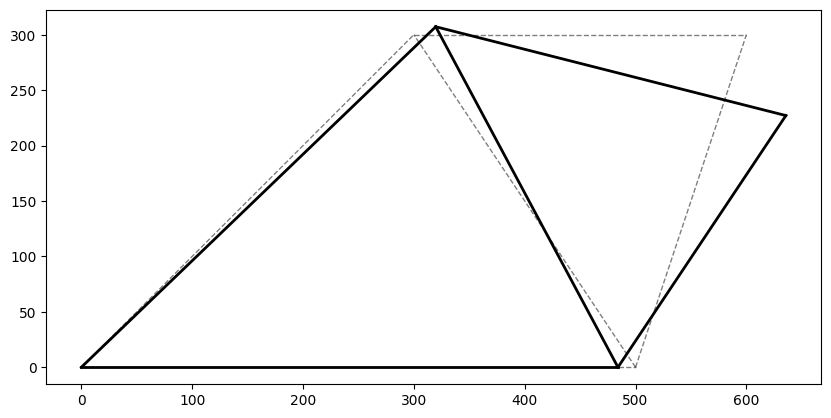

In [46]:
# | code-fold: true
# | label: fig-deformed-shape
plt.style.use("default")
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_aspect("equal")

# Amplification factor for visualization
scale = 80

# Plot undeformed structure
for n1, n2 in elements:
    p1 = nodes[n1]
    p2 = nodes[n2]
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], "k--", linewidth=1, alpha=0.5)

# Plot deformed structure
for n1, n2 in elements:
    p1 = nodes[n1] + scale * U[n1]
    p2 = nodes[n2] + scale * U[n2]
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], "k-", linewidth=2)

### Computing Member Quantities

Once the displacements have been computed we can compute the normal forces, resultant forces, deformations, strains and stresses.


In [47]:
# | code-fold: false
React = np.zeros(nnod * 2)  # Reaction forces in the nodes, two DOF per node
delta = np.zeros(nele)  # Element deformations
N = delta.copy()  # Normal forces in the elements
epsilon = delta.copy()  # Strains in the elements
sigma = delta.copy()  # Stresses in the elements

for iel, (n1, n2) in enumerate(elements):
    r = nodes[n2] - nodes[n1]
    L = np.linalg.norm(r)
    c, s = r / L
    T = np.array([-c, -s, c, s])

    Ai = A[iel]
    Ei = E[iel]
    Ki = Ei * Ai / L

    dofs = np.array([2 * n1, 2 * n1 + 1, 2 * n2, 2 * n2 + 1])

    ue = u[dofs]
    delta_i = T @ ue
    N_i = Ki * delta_i
    fe = N_i * T
    epsilon_i = delta_i / L
    sigma_i = N_i / Ai

    React[dofs] += fe
    N[iel] = N_i
    delta[iel] = delta_i
    epsilon[iel] = epsilon_i
    sigma[iel] = sigma_i


# Split reactions into x and y components for clarity
Rx = React[0::2]
Ry = React[1::2]
R = np.array([Rx, Ry]).T

In [48]:
# | echo: false
display_labeled_latex("\\mathbf{{R}} = ", R,0)

<IPython.core.display.Latex object>

### Visualize element results on deformed shape

In [ ]:
# Plot the member stresses on the deformed shape
# | code-fold: true
# | label: fig-deformed-shape-stress
plt.style.use("default")
fig, ax = plt.subplots(figsize=(10, 8))

# Amplification factor for visualization
scale = 80

# Plot undeformed structure with mk.patch()
mk.patch('Faces', elements, 'Vertices', nodes,
         'EdgeColor', 'k', 'LineWidth', 1, 'LineStyle', '--', 'alpha', 0.5)

# Plot deformed structure with color-coded stress
deformed_nodes = nodes + scale * u.reshape(-1, 2)

collection, mappable = mk.patch(
    'Faces', elements,
    'Vertices', deformed_nodes,
    'FaceVertexCData', sigma,  # Element-wise stress data
    'LineWidth', 3,
    'cmap', 'jet',
    return_mappable=True
)

# Plot nodes
ax.scatter(deformed_nodes[:, 0], deformed_nodes[:, 1], c="k", s=100, zorder=5)

# Add element labels at midpoints of deformed elements
for i, (n1, n2) in enumerate(elements):
    mid_point = (deformed_nodes[n1] + deformed_nodes[n2]) / 2
    ax.text(
        mid_point[0],
        mid_point[1],
        str(f"$\\sigma={sigma[i]:.2f}$ MPa"),
        backgroundcolor="w",
        horizontalalignment="center",
        verticalalignment="center",
        fontsize=10,
        fontweight="normal",
    )

# Add colorbar - simplified with mappable
cbar = plt.colorbar(mappable, ax=ax, shrink=0.4)
cbar.set_label("Stress [MPa]", fontsize=12)

ax.set_xlabel("x [mm]", fontsize=12)
ax.set_ylabel("y [mm]", fontsize=12)
ax.set_title(f"Deformed Shape (Scale Factor: {scale}×)", fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

In [ ]:
# Plot the member force on the deformed shape
# | code-fold: true
# | label: fig-deformed-shape-force
plt.style.use("default")
fig, ax = plt.subplots(figsize=(10, 8))

# Amplification factor for visualization
scale = 80

# Plot undeformed structure with mk.patch()
mk.patch('Faces', elements, 'Vertices', nodes,
         'EdgeColor', 'k', 'LineWidth', 1, 'LineStyle', '--', 'alpha', 0.5)

# Plot deformed structure with color-coded forces
deformed_nodes = nodes + scale * u.reshape(-1, 2)

collection, mappable = mk.patch(
    'Faces', elements,
    'Vertices', deformed_nodes,
    'FaceVertexCData', N,  # Element-wise force data
    'LineWidth', 3,
    'cmap', 'jet',
    return_mappable=True
)

# Plot nodes
ax.scatter(deformed_nodes[:, 0], deformed_nodes[:, 1], c="k", s=100, zorder=5)

# Add element labels at midpoints of deformed elements
for i, (n1, n2) in enumerate(elements):
    mid_point = (deformed_nodes[n1] + deformed_nodes[n2]) / 2
    ax.text(
        mid_point[0],
        mid_point[1],
        str(f"$N={N[i]:.0f}$ N"),
        backgroundcolor="w",
        horizontalalignment="center",
        verticalalignment="center",
        fontsize=10,
        fontweight="normal",
    )

# Add colorbar - simplified with mappable
cbar = plt.colorbar(mappable, ax=ax, shrink=0.4)
cbar.set_label("Element force [N]", fontsize=12)

ax.set_xlabel("x [mm]", fontsize=12)
ax.set_ylabel("y [mm]", fontsize=12)
ax.set_title(f"Deformed Shape (Scale Factor: {scale}×)", fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

In [ ]:
# Plot the member deformation on the deformed shape
# | code-fold: true
# | label: fig-deformed-shape-deformation
plt.style.use("default")
fig, ax = plt.subplots(figsize=(10, 8))

# Amplification factor for visualization
scale = 80

# Plot undeformed structure with mk.patch()
mk.patch('Faces', elements, 'Vertices', nodes,
         'EdgeColor', 'k', 'LineWidth', 1, 'LineStyle', '--', 'alpha', 0.5)

# Plot deformed structure with color-coded deformation
deformed_nodes = nodes + scale * u.reshape(-1, 2)

collection, mappable = mk.patch(
    'Faces', elements,
    'Vertices', deformed_nodes,
    'FaceVertexCData', delta,  # Element-wise deformation data
    'LineWidth', 3,
    'cmap', 'jet',
    return_mappable=True
)

# Plot nodes
ax.scatter(deformed_nodes[:, 0], deformed_nodes[:, 1], c="k", s=100, zorder=5)

# Add element labels at midpoints of deformed elements
for i, (n1, n2) in enumerate(elements):
    mid_point = (deformed_nodes[n1] + deformed_nodes[n2]) / 2
    ax.text(
        mid_point[0],
        mid_point[1],
        str(f"$\\delta={delta[i]:.3f}$ mm"),
        backgroundcolor="w",
        horizontalalignment="center",
        verticalalignment="center",
        fontsize=10,
        fontweight="normal",
    )

# Add colorbar - simplified with mappable
cbar = plt.colorbar(mappable, ax=ax, shrink=0.4)
cbar.set_label("Element deformation [mm]", fontsize=12)

ax.set_xlabel("x [mm]", fontsize=12)
ax.set_ylabel("y [mm]", fontsize=12)
ax.set_title(f"Deformed Shape (Scale Factor: {scale}×)", fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

In [ ]:
# Plot the member strain on the deformed shape
# | code-fold: true
# | label: fig-deformed-shape-strain
plt.style.use("default")
fig, ax = plt.subplots(figsize=(10, 8))

# Amplification factor for visualization
scale = 80

# Plot undeformed structure with mk.patch()
mk.patch('Faces', elements, 'Vertices', nodes,
         'EdgeColor', 'k', 'LineWidth', 1, 'LineStyle', '--', 'alpha', 0.5)

# Plot deformed structure with color-coded strain
deformed_nodes = nodes + scale * u.reshape(-1, 2)

collection, mappable = mk.patch(
    'Faces', elements,
    'Vertices', deformed_nodes,
    'FaceVertexCData', epsilon,  # Element-wise strain data
    'LineWidth', 3,
    'cmap', 'jet',
    return_mappable=True
)

# Plot nodes
ax.scatter(deformed_nodes[:, 0], deformed_nodes[:, 1], c="k", s=100, zorder=5)

# Add element labels at midpoints of deformed elements
for i, (n1, n2) in enumerate(elements):
    mid_point = (deformed_nodes[n1] + deformed_nodes[n2]) / 2
    ax.text(
        mid_point[0],
        mid_point[1],
        str(f"$\\varepsilon={epsilon[i]*100:.3f}$ %"),
        backgroundcolor="w",
        horizontalalignment="center",
        verticalalignment="center",
        fontsize=10,
        fontweight="normal",
    )

# Add colorbar - simplified with mappable
cbar = plt.colorbar(mappable, ax=ax, shrink=0.4)
cbar.set_label("Element strain [%]", fontsize=12)

ax.set_xlabel("x [mm]", fontsize=12)
ax.set_ylabel("y [mm]", fontsize=12)
ax.set_title(f"Deformed Shape (Scale Factor: {scale}×)", fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Example: Prescribed Displacements


Here, in addition for nodal forces, we also have nodes with prescribed displacements which are non-zero. This is the same as deforming a spring to a certain length, it will correspond to a force, but we control the displacement instead.

![Prescribed displacement in node 2](graphics/SystematicTrussAnalysis_PrescribedDisplacements.png){fig-align="center" width=400}

Given: $\delta=1$ mm. $P=10$ kN.

Find the deformed shape, member forces and reaction force in node 2.

In [53]:
# | code-fold: false
import numpy as np
import matplotlib.pyplot as plt

# Node coordinates [x, y] in mm
nodes = np.array(
    [
        [0, 0],  # Node 1
        [600, 0],  # Node 2
        [400, 200],  # Node 3
        [0, 200],  # Node 4
    ]
)

# Element connectivity (0-indexed)
elements = np.array(
    [
        [0, 1],  # Element 1
        [2, 3],  # Element 2
        [0, 2],  # Element 3
        [2, 1],  # Element 4
    ]
)

Initiate variables

In [54]:
# | code-fold: false
nele = elements.shape[0]  # number of elements
nnod = nodes.shape[0]  # number of nodes
ndofs = nnod * 2  # 2 DOF per node (u_x, u_y)

S = np.zeros((ndofs, ndofs))  # Global stiffness matrix
f = np.zeros(ndofs)  # Global force vector
u = np.zeros(ndofs)  # Global displacement vector
Sprime = np.array([[1, 0, -1, 0], [0, 0, 0, 0], [-1, 0, 1, 0], [0, 0, 0, 0]])
Ltot = 0  # Total length of truss
E = 210000 * np.ones(nele)  # Young's modulus in MPa
A = 4 * 6 * np.ones(nele)  # Cross-sectional area in mm^2

print(f"Number of elements: {nele}")
print(f"Number of nodes: {nnod}")

Number of elements: 4
Number of nodes: 4


Visualize  the structure

In [ ]:
# | code-fold: true
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.set_aspect("equal")
ax.axis("off")
ax.set_xlim(-50, 650)
ax.set_ylim(-50, 250)

# Draw elements using mk.patch()
mk.patch('Faces', elements, 'Vertices', nodes,
         'EdgeColor', 'black', 'LineWidth', 2)

# Node dots
ax.plot(
    nodes[:, 0],
    nodes[:, 1],
    marker="o",
    markeredgecolor="k",
    markerfacecolor="c",
    markersize=14,
    linestyle="None",
)

nnod = nodes.shape[0]

# Node numbering
for i in range(nnod):
    # Use str(i + 1) to get 1-based node numbers
    ax.text(
        nodes[i, 0] + 3,
        nodes[i, 1],
        str(i + 1),
        horizontalalignment="right",  # 'right' aligns text left of point
        verticalalignment="center",
        fontsize=8,
    )

# Element numbering
# We use enumerate to get a 0-based index 'i'
for i, element_nodes in enumerate(elements):
    # Find the midpoint of the element
    mid_point = np.mean(nodes[element_nodes], axis=0)
    xm = mid_point[0]
    ym = mid_point[1]

    # We use str(i + 1) to get 1-based element numbers
    label = str(i + 1)
    ax.text(
        xm,
        ym,
        label,
        backgroundcolor="y",
        horizontalalignment="center",
        verticalalignment="center",
        fontsize=8,
        fontweight="normal",
    )

In [56]:
# | code-fold: false
for iel, (n1, n2) in enumerate(elements):
    r = nodes[n2] - nodes[n1]
    L = np.linalg.norm(r)
    Ltot += L
    c, s = r / L
    R = np.array([[c, -s], [s, c]])
    LT = np.block([[R, np.zeros((2, 2))], [np.zeros((2, 2)), R]])
    Ai = A[iel]
    Ei = E[iel]
    Ki = Ei * Ai / L
    Se = Ki * LT @ Sprime @ LT.T
    dofs = np.array([2 * n1, 2 * n1 + 1, 2 * n2, 2 * n2 + 1])
    # print(Se)
    S[np.ix_(dofs, dofs)] += Se

In [57]:
# | code-fold: false
presc = np.array([0, 1, 2, 6, 7])  # Prescribed DOFs (0-based)
u[presc] = [0,0,2,0,0]  # Prescribed displacements in mm

# Loads
f[3*2-1] = -10000.0  # Load in N at node 3 in negative y-direction

free = np.setdiff1d(np.arange(nnod * 2), presc)

fr = S[np.ix_(free, presc)] @ u[presc]


Sfree = S[np.ix_(free, free)]
fr_total = f[free] - fr


u_free = np.linalg.solve(Sfree, fr_total)
u[free] = u_free

In [58]:
f

array([     0.,      0.,      0.,      0.,      0., -10000.,      0.,
            0.])

In [59]:
fr

array([-17819.0908859, -17819.0908859,  17819.0908859])

In [60]:
fr_total

array([ 17819.0908859,  17819.0908859, -27819.0908859])

In [61]:
# | code-fold: false
U = u.reshape((nnod, 2))


In [62]:
# | echo: false
display_labeled_latex("\\mathbf U = ", U,4)

<IPython.core.display.Latex object>

In [63]:
UR = np.sum(U**2, axis=1) ** 0.5

In [64]:
# | echo: false
display_labeled_latex("\\mathbf{{UR}} = ", UR,4)

<IPython.core.display.Latex object>

In [65]:
# | code-fold: false
React = np.zeros(nnod * 2)  # Reaction forces in the nodes, two DOF per node
delta = np.zeros(nele)  # Element deformations
N = delta.copy()  # Normal forces in the elements
epsilon = delta.copy()  # Strains in the elements
sigma = delta.copy()  # Stresses in the elements

for iel, (n1, n2) in enumerate(elements):
    r = nodes[n2] - nodes[n1]
    L = np.linalg.norm(r)
    c, s = r / L
    T = np.array([-c, -s, c, s])

    Ai = A[iel]
    Ei = E[iel]
    Ki = Ei * Ai / L

    dofs = np.array([2 * n1, 2 * n1 + 1, 2 * n2, 2 * n2 + 1])

    ue = u[dofs]
    delta_i = T @ ue
    N_i = Ki * delta_i
    fe = N_i * T
    epsilon_i = delta_i / L
    sigma_i = N_i / Ai

    React[dofs] += fe
    N[iel] = N_i
    delta[iel] = delta_i
    epsilon[iel] = epsilon_i
    sigma[iel] = sigma_i


# Split reactions into x and y components for clarity
Rx = React[0::2]
Ry = React[1::2]
R = np.array([Rx, Ry]).T

In [66]:
# | echo: false
display_labeled_latex("\\mathbf{{R}} = ", R,0)

<IPython.core.display.Latex object>

In [ ]:
# | code-fold: true
import numpy as np                                                                       
import matplotlib.pyplot as plt                                                          

def visualize_deformed_truss(nodes, elements, U, cdata, scale_factor=1.0, use_interpolation=True):                  
    """                                                                                  
    Visualizes the deformed shape of a truss with element colors.                         
                                                                                          
    Parameters                                                                           
    ----------                                                                           
    nodes : np.ndarray                                                                   
        Array of node coordinates, shape (num_nodes, 2).                                 
    elements : np.ndarray                                                                
        Array of element connectivity, shape (num_elements, 2).                          
    U : np.ndarray
        Displacement vector for all nodes.
    cdata : np.ndarray
        Color data - either per-node (for interpolation) or per-element (for flat colors).
    scale_factor : float
        Deformation scaling factor for visualization.
    use_interpolation : bool
        If True, interpolates colors between nodes. If False, uses flat element colors.
    """  
    
    # Apply deformation
    deformed_nodes = nodes + scale_factor * U.reshape(-1, 2)
    
    # --- Plotting with mk.patch() ---                                                                   
    fig, ax = plt.subplots(figsize=(12, 8))                                              
    
    if use_interpolation:
        # Node-based interpolation: smooth gradient along elements
        collection, mappable = mk.patch(
            'Faces', elements,
            'Vertices', deformed_nodes,
            'FaceVertexCData', cdata,
            'FaceColor', 'interp',  # Automatic interpolation
            'LineWidth', 3,
            'cmap', 'viridis',
            return_mappable=True
        )
    else:
        # Element-based: flat coloring per element
        collection, mappable = mk.patch(
            'Faces', elements,
            'Vertices', deformed_nodes,
            'FaceVertexCData', cdata,
            'LineWidth', 3,
            'cmap', 'viridis',
            return_mappable=True
        )
    
    # Add colorbar - simplified with mappable
    cbar = fig.colorbar(mappable, ax=ax)
    cbar.set_label('Color Data')
    
    # Set plot limits and aspect ratio                                                   
    ax.autoscale()                                                                       
    ax.set_aspect('equal', adjustable='box')                                             
    ax.set_title(f'Deformed Truss Shape (Scale: {scale_factor})')         
    ax.set_xlabel('X-coordinate')                                                        
    ax.set_ylabel('Y-coordinate')                                                        
    ax.grid(True, linestyle='--', alpha=0.6)                                             
                                                                                         
    plt.show()

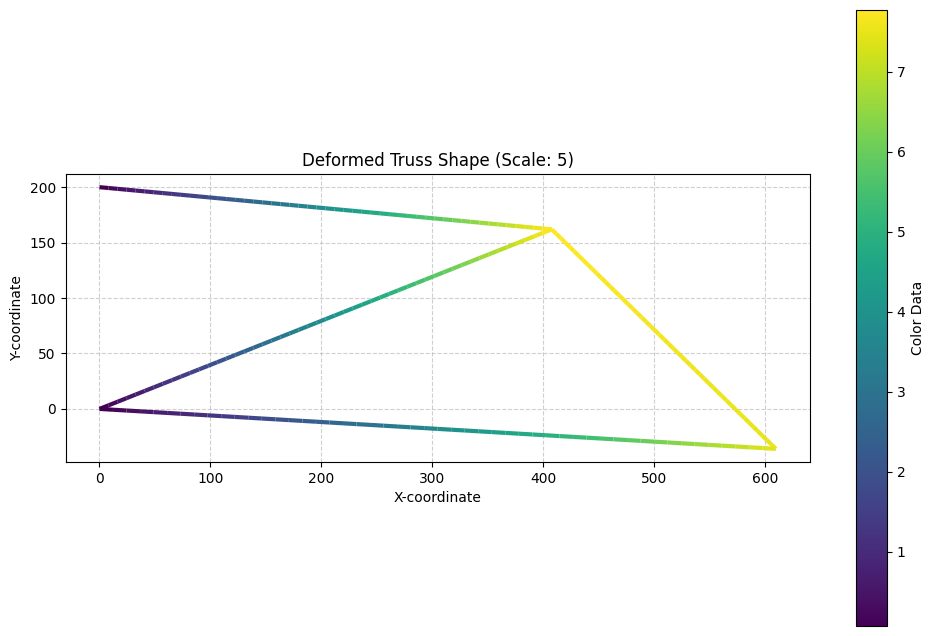

In [68]:
visualize_deformed_truss(nodes, elements, U, UR, scale_factor=5)

## References

The direct stiffness method for truss structures follows standard treatments in structural mechanics textbooks. For further reading on matrix methods in structural analysis, see @McGuire2000, @Kassimali2012, @Hibbeler2012, and @Przemieneicki1968. A comprehensive treatment of the finite element method, which builds upon these matrix methods, can be found in @Felippa2004, @Ottosen1992, and @Cook2001.